In [33]:
import numpy as np
from matplotlib import pyplot as plt

# Grab a single npz test file
### This assumes the test file is generated from scripts/icetray/step1/monitoring_extractors/pass3_charge_fadc_gain.py

In [34]:
x = np.load("./testing_133575.fadc_atwd_charge.npz")
print(x)

NpzFile './testing_133575.fadc_atwd_charge.npz' with keys: start, atwd, fadc, bins


/tmp/ipykernel_3168424/1230586507.py:49: RuntimeWarning: divide by zero encountered in divide
  atwd/fadc,
/tmp/ipykernel_3168424/1230586507.py:49: RuntimeWarning: invalid value encountered in divide
  atwd/fadc,


Text(0, 0.5, 'ATWD/FADC')

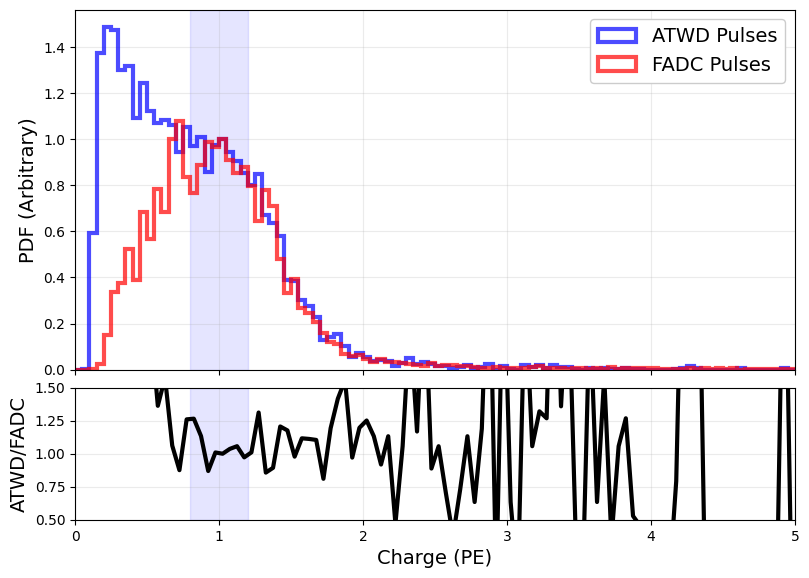

In [37]:
### Plot the ATWD, FADC histograms for a single OMKey
omkey = (21, 42)

fig = plt.figure(figsize=(8,6))
ax0 = fig.add_axes([0.05, 0.35, 0.9, 0.6])
ax1 = fig.add_axes([0.05, 0.10, 0.9, 0.22])

# DST digitizes these in an awkward way. Merge neighboring bins.
def merge(hist):
    return hist[0::2] + hist[1::2]
bins = x['bins'][::2]
atwd_hist = merge(x['atwd'][omkey])
fadc_hist = merge(x['fadc'][omkey])

# Find the bin corresponding to Q~1 for normalizations
norm_bin = np.searchsorted(bins, 1)

atwd, bins, _ = ax0.hist(bins[:-1],
                         bins = bins,
                         weights = atwd_hist / atwd_hist[norm_bin],
                         histtype = 'step',
                         linewidth=3,
                         color = 'b',
                         alpha = 0.7,
                         label = 'ATWD Pulses')
fadc, bins, _ = ax0.hist(bins[:-1],
                         bins = bins,
                         weights = fadc_hist / fadc_hist[norm_bin],
                         histtype = 'step',
                         linewidth=3,
                         color = 'r',
                         alpha = 0.7,
                         label = 'FADC Pulses')

# Highlight the fit region
ax0.axvspan(0.8, 1.2, 
            color='b',
            alpha=0.1)

ax0.grid(alpha=0.25)
ax0.tick_params(labelsize=10)
ax0.set_xticklabels([])
ax0.set_xlim(x['bins'].min(), x['bins'].max())
ax0.set_ylabel("PDF (Arbitrary)", fontsize=14)
ax0.legend(loc='upper right', framealpha=1, fontsize=14)

# And plot the ratio so we can see how well it corresponds
ax1.plot(bins[:-1]+np.diff(bins)/2,
          atwd/fadc,
         color='k',
        linewidth=3,)
# Highlight the fit region
ax1.axvspan(0.8, 1.2, 
            color='b',
            alpha=0.1)
ax1.grid(alpha=0.25)
ax1.tick_params(labelsize=10)
ax1.set_xlim(*ax0.get_xlim())
ax1.set_xlabel("Charge (PE)", fontsize=14)
ax1.set_ylim(0.5, 1.5)
ax1.set_ylabel("ATWD/FADC", fontsize=14)
